2.	Go to the PEER Strong Motion Database (NGA-West2: http://ngawest2.berkeley.edu/) and download the acceleration time history: FRE000 component, Fremont-Mission San Jose station, 1989, Mw6.9 Loma Prieta, California, earthquake. Provide the following information: 
    1. Plot the acceleration time history; plot in units of g. 
    2. Compute and plot the velocity time history; plot in units of cm/sec. 
    3. Compute and plot the displacement time history; plot in units of cm.


In [26]:
import numpy as np
from obspy import Trace, Stream
import matplotlib.pyplot as plt
from scipy import signal

The downloaded file *RSN762_LOMAP_FRE000.AT2* is for one single component. The numbers are arranged in time order from left to right, line by line. Each individual number represents the ground acceleration at one specific time step ($\Delta t = 0.005\text{ seconds}$).Row 1 (Line 5) has values 1 through 5 (from $t = 0.000\text{s}$ to $t = 0.020\text{s}$).Row 2 (Line 6) has values 6 through 10 (from $t = 0.025\text{s}$ to $t = 0.045\text{s}$). When Python parses the text file with .split() or np.fromstring(), it ignores all line breaks and spaces, unwrapping those wrapped rows back into a single 1D array of 7,998 consecutive acceleration values:$$\text{data\_g} = [\text{acc}_0, \text{acc}_1, \text{acc}_2, \dots, \text{acc}_{7997}]$$

In [23]:
# First we must set up the time series properly for Obspy
filename = "RSN762_LOMAP_FRE000.AT2"

# Read header for time step (DT)
with open(filename, "r") as f:
    lines = f.readlines()
    dt = 0.005 # found in file
    data_text = " ".join(lines[4:]) # Extract all text from line 4 onwards (skipping the 4 header lines)

# Make 1D array, ignoring row structure from file
data_g = np.fromstring(data_text, sep=" ")

# Wrap into ObsPy Trace
tr = Trace(data=data_g)
tr.stats.delta = dt
tr.stats.network = "PEER"
tr.stats.station = "FRE"
tr.stats.channel = "000"

st = Stream(traces=[tr])

We proceed in the plottign of the acceleration time history. It's important to note that the acceleration file was downloaded from the PEER NGA - Wst 2 database, and as it stated, it is a **processed** database. Meaning, PEER has already performed:

    1. Intrument Response Removal
    2. Frequency filtering/Bandpass
    3. Baseline Correction

Therefore we focused our effors to convering acceleration to cm/s^2, and afterwards integrating to velocity and displacement.

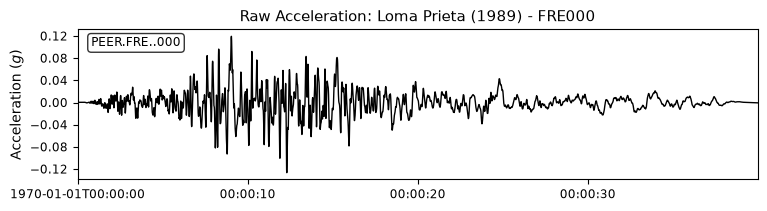

In [37]:
# Plot the acceleration time history; plot in units of g. 
# Raw plot data
fig = st.plot(handle=True)
fig.suptitle("")  # Clear ObsPy auto timestamp header

ax = fig.axes[0]
ax.set_title("Raw Acceleration: Loma Prieta (1989) - FRE000", fontsize=11)
ax.set_ylabel("Acceleration ($g$)")

plt.show()

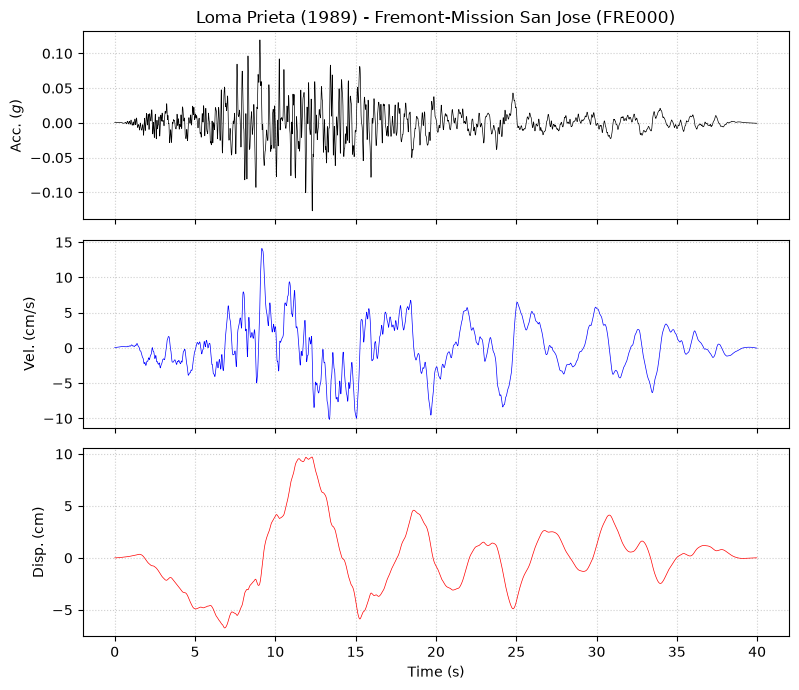

In [41]:
# Compute and plot the velocity time history; plot in units of cm/sec.
# Prepare Acceleration Stream (in cm/s^2)
st_acc = st.copy()
st_acc.detrend("linear")

# Scale acceleration trace values from g to cm/s^2 directly in ObsPy
st_acc[0].data = st_acc[0].data * 980.665

# Determine Velocity Stream (cm/s)
st_vel = st_acc.copy()
st_vel.integrate(method="cumtrapz")
st_vel.detrend("linear")  # Remove baseline drift from integration

# Determine Displacement Stream (cm)
st_disp = st_vel.copy()
st_disp.integrate(method="cumtrapz")

# Plot
fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

# Acceleration Plot 
axs[0].plot(st_acc[0].times(), st_acc[0].data / 980.665, color="black", linewidth=0.5)
axs[0].set_ylabel("Acc. ($g$)")
axs[0].set_title("Loma Prieta (1989) - Fremont-Mission San Jose (FRE000)")
axs[0].grid(True, linestyle=":", alpha=0.6)

# Velocity Plot (cm/s)
axs[1].plot(st_vel[0].times(), st_vel[0].data, color="blue", linewidth=0.5)
axs[1].set_ylabel("Vel. (cm/s)")
axs[1].grid(True, linestyle=":", alpha=0.6)

# Displacement Plot (cm)
axs[2].plot(st_disp[0].times(), st_disp[0].data, color="red", linewidth=0.5)
axs[2].set_ylabel("Disp. (cm)")
axs[2].set_xlabel("Time (s)")
axs[2].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

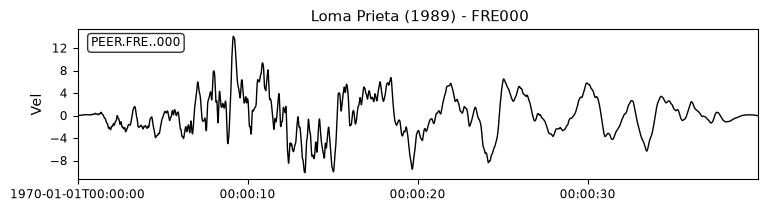

In [42]:
# First we must set up the time series properly for Obspy
filename = "RSN762_LOMAP_FRE000.VT2"

# Read header for time step (DT)
with open(filename, "r") as f:
    lines = f.readlines()
    dt = 0.005 # found in file
    data_text = " ".join(lines[4:]) # Extract all text from line 4 onwards (skipping the 4 header lines)

# Make 1D array, ignoring row structure from file
data_g = np.fromstring(data_text, sep=" ")

# Wrap into ObsPy Trace
tr = Trace(data=data_g)
tr.stats.delta = dt
tr.stats.network = "PEER"
tr.stats.station = "FRE"
tr.stats.channel = "000"

st = Stream(traces=[tr])
# Plot the acceleration time history; plot in units of g. 
# Raw plot data
fig = st.plot(handle=True)
fig.suptitle("")  # Clear ObsPy auto timestamp header

ax = fig.axes[0]
ax.set_title(" Loma Prieta (1989) - FRE000", fontsize=11)
ax.set_ylabel("Vel")

plt.show()

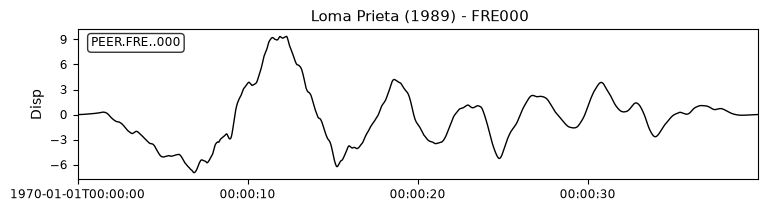

In [43]:
# First we must set up the time series properly for Obspy
filename = "RSN762_LOMAP_FRE000.DT2"

# Read header for time step (DT)
with open(filename, "r") as f:
    lines = f.readlines()
    dt = 0.005 # found in file
    data_text = " ".join(lines[4:]) # Extract all text from line 4 onwards (skipping the 4 header lines)

# Make 1D array, ignoring row structure from file
data_g = np.fromstring(data_text, sep=" ")

# Wrap into ObsPy Trace
tr = Trace(data=data_g)
tr.stats.delta = dt
tr.stats.network = "PEER"
tr.stats.station = "FRE"
tr.stats.channel = "000"

st = Stream(traces=[tr])
# Plot the acceleration time history; plot in units of g. 
# Raw plot data
fig = st.plot(handle=True)
fig.suptitle("")  # Clear ObsPy auto timestamp header

ax = fig.axes[0]
ax.set_title(" Loma Prieta (1989) - FRE000", fontsize=11)
ax.set_ylabel("Disp")

plt.show()